Running N=2000: 100%|██████████| 3000/3000 [00:15<00:00, 197.42it/s]


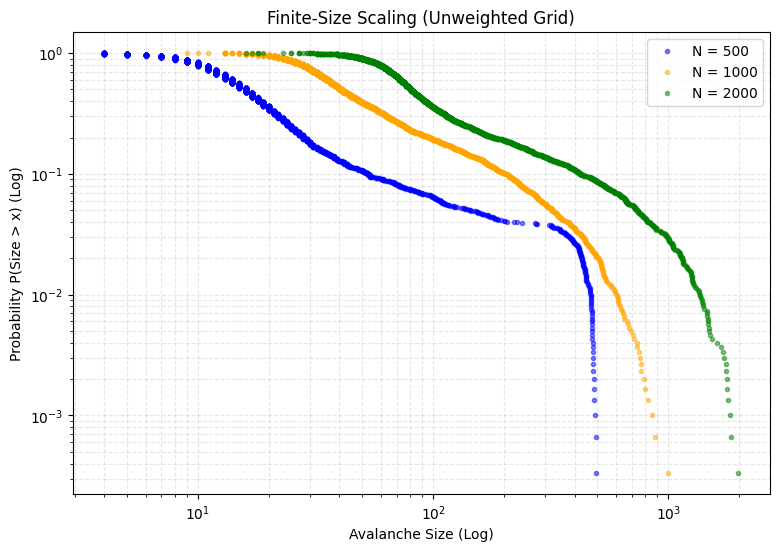

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_avalanches_scaled(N, base_N=1000, base_R=0.05):
    # CRITICAL MATH: Scale radius to keep average connections per node constant
    target_degree = base_N * np.pi * (base_R**2)
    adjusted_R = np.sqrt(target_degree / (N * np.pi))

    TOL, NOISE, STEPS = 0.15, 0.8, 3000

    # 1. Build UNWEIGHTED scaled network
    G = nx.random_geometric_graph(N, radius=adjusted_R)

    for node in G.nodes():
        load = np.random.uniform(0, 10)
        G.nodes[node]['load'] = load
        G.nodes[node]['capacity'] = load * (1 + TOL)
        G.nodes[node]['tripped'] = False

    avalanches = []

    # 2. Run Simulation
    for step in tqdm(range(STEPS), desc=f"Running N={N}"):
        for node in G.nodes():
            G.nodes[node]['load'] += (NOISE / 10.0)

        current_size = 0

        while True:
            overloaded = [n for n, d in G.nodes(data=True) if d['load'] > d['capacity'] and not d['tripped']]
            if not overloaded: break

            for node in overloaded:
                overload_amt = G.nodes[node]['load']
                G.nodes[node]['load'] = 0
                G.nodes[node]['tripped'] = True
                current_size += 1

                # EQUAL REDISTRIBUTION
                active_nbrs = [nbr for nbr in G.neighbors(node) if not G.nodes[nbr]['tripped']]
                if active_nbrs:
                    spill = overload_amt / len(active_nbrs)
                    for nbr in active_nbrs:
                        G.nodes[nbr]['load'] += spill

        if current_size > 0:
            avalanches.append(current_size)

        for node in G.nodes(): G.nodes[node]['tripped'] = False

    return avalanches

# --- THE FINITE-SIZE SCALING EXECUTION ---
sizes_to_test = [500, 1000, 2000]
colors = ['blue', 'orange', 'green']

plt.figure(figsize=(9, 6))

for i, N in enumerate(sizes_to_test):
    data = get_avalanches_scaled(N)
    if data:
        sorted_sizes = np.sort(data)[::-1]
        probs = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes)
        plt.loglog(sorted_sizes, probs, marker='.', linestyle='none', color=colors[i], alpha=0.5, label=f"N = {N}")

# --- PLOTTING ---
plt.title("Finite-Size Scaling (Unweighted Grid)")
plt.xlabel("Avalanche Size (Log)")
plt.ylabel("Probability P(Size > x) (Log)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()